In [2]:
import pymnet
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import openpyxl
import numpy as np

# Explore database

In [3]:
import sqlite3

db_path = "../../industrial_cluster.db"
conn = sqlite3.connect(db_path)

# Show all tables in the database
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query, conn)
# print(tables)

# Show all columns in the 'components' table
query = "PRAGMA table_info('components');"
columns = pd.read_sql_query(query, conn)
# print(columns)

# Show all records in the 'components' table with columns "component_id" and "name"
query = "SELECT component_id, name FROM components;"
components = pd.read_sql_query(query, conn)
display(components)

,component_id,name
0,CM001,"1,1,1,2-Tetrachloroethane"
1,CM002,"1,1,1,2-Tetrafluoroethane"
2,CM003,"1,1,2-Trichloroethane"
3,CM004,"1,2,3-Trichloropropane"
4,CM005,"1,2,4-Trimethylbenzene"
...,...,...
229,CM249,Pyridine/Pyrrole
230,CM255,food waste
231,CM258,METHY-01
232,CM259,METHY-02


# Calculate Material KPIs

In [44]:
import sqlite3

# ── Configuration ─────────────────────────────────────────────────────────────

# DB company_id -> short "Company" name used by the energy KPI merge / heatmap.
# These 6 are exactly the companies flagged included=1 in industrial_cluster.db.
COMPANY_NAME_MAP = {
    "C002": "CHP plant",
    "C003": "Olefins plant",
    "C004": "Aromatics plant",
    "C005": "Biogas plant",
    "C010": "Methanol plant",
    "C013": "DME plant",
}

# Source: https://ghgprotocol.org/sites/default/files/2024-08/Global-Warming-Potential-Values%20%28August%202024%29.pdf
GHG_EMISSION_COMPONENTS_TO_CO2E = {
    "CM055": 1.0,  # Carbon dioxide
    "CM063": 20.6,  # Chloroform
    "CM072": 771.0,  # Difluoromethane
    "CM089": 1350.0,  # Fluoromethane
    "CM111": 25.0,  # Methane
    "CM115": 5.54,  # Methyl chloride
    "CM117": 135.0,  # Methyl fluoride
    "CM142": 273.0,  # Nitrous oxide
    "CM206": 2200.0,  # Tetrachloromethane
}

# KPI 3 (Recycled Input Materials) is computed from the flows graph
# (see compute_recycled_input_kt). This manual map is an OVERRIDE: companies
# listed here keep this fixed fraction regardless of the computed value
# (the computed value is used for every company not listed). Default 0.0.
RECYCLED_FRACTION_MAP = {
    "Biogas plant": 1.0,
}

# Generic Water WMF node (waste_facility): takes wastewater via waste_to_wmf
# flows and returns processed water via internal flows. Its water output counts
# as recycled input for the receiving plants (KPI 3).
WATER_WMF_COMPANY_ID = "C019"

# Flow statuses treated as active connections when reading the flows topology.
ACTIVE_FLOW_STATUSES = ("candidate", "confirmed")

# Manual recycled-input override: (company_id, to_stream_id) -> recycled kt/year.
# Forces a specific recycled amount for an input stream, replacing whatever the
# flow-based rule computed. Values must be on the SAME SCALED BASIS as the rest
# of the calculation (i.e. already multiplied by the company's scaling_factor).
# Normally empty: the Olefins flue-gas CO2 -> Methanol FS-CO2 case (F018, a
# waste-sourced feedstock flow) is picked up automatically and correctly scaled.
RECYCLED_INPUT_KT_OVERRIDE = {
    # ("C010", "S129"): 124.26,  # example: pin Methanol FS-CO2 recycled feedstock
}

# CO2 captured and utilised per company (kt/year) — subtracted from gross co2_out_kt
# to give a net GHG emission value for KPI 2. Default 0.0 for unlisted companies.
# CO2 has GWP=1.0, so kt CO2 captured == kt CO2e captured; units are consistent.
CO2_CAPTURED_KT = {
    # "Olefins plant": 124.260, # Fullfiling the CO2 feedstock need of methanol plant
    "Olefins plant": 2820.4429194,  # Fullfiling the full capture of the flue gas of the olefins plant
}

# Per-company explicit wastewater stream IDs (keyed by company_id).
# When a company_id is listed here, its waste_water_kt is computed from these
# streams instead of from CM226 composition across all waste streams.
# Companies absent from this dict fall back to composition-based water content.
WASTEWATER_STREAM_IDS = {
    "C003": ["S038", "S039", "S040", "S043"],  # Olefins wastewater streams
    "C005": ["S080", "S079"],  # Biogas digestate water
    "C010": ["S136", "S137"],  # Methanol wastewater streams
    "C013": ["S158"],  # DME wastewater
    "C002": [],  # CHP plant has no wastewater streams
    "C004": ["S072"],  # Aromatics plant has no wastewater streams
}

# True  → designated streams contribute their full scaled_flow as waste_water_kt
#          (the entire stream is wastewater).
# False → only the CM226 content (scaled_flow × water fraction) of those streams
#          counts — consistent with the composition-based fallback method.
WASTEWATER_FULL_FLOW = False

# Per-company explicit GHG emission stream IDs (keyed by company_id).
# When a company_id is listed here, its co2_out_kt is computed from these
# streams instead of from GHG_EMISSION_COMPONENTS_TO_CO2E composition across all output streams.
# Companies absent from this dict fall back to composition-based CO2e content.
GHG_EMISSION_STREAM_IDS = {
    "C005": [],  # Biogas plant has none
    "C002": ["S016"],  # CHP plant: Fluegas (S016)
    "C003": ["S037"],  # Olefins: Fluegas (S037)
    "C004": [],  # Aromatics: no GHG emissions
    "C010": ["S133", "S134", "S135"],  # Methanol: Fluegas + WS-LIGHT + WS-PURGE
    "C013": [],  # DME: no GHG emissions
}

# True  → designated streams contribute their full scaled_flow as co2_out_kt
#          (treat the entire stream as CO2e, e.g. a pure CO2 vent stream).
# False → only the CO2e content (scaled_flow × GHG fractions × GWP factors) of those streams
#          counts — consistent with the composition-based fallback method.
GHG_EMISSION_FULL_FLOW = False

WATER_COMPONENT_ID = "CM226"  # H2O


# ══════════════════════════════════════════════════════════════════════════════
# Recycled-input computation (KPI 3, from the flows graph)
# ══════════════════════════════════════════════════════════════════════════════
#
# KPI 3 (Recycled Input Materials) measures how much of a plant's input comes
# from a recycled/recovered source rather than virgin feedstock. The connections
# live in the `flows` table as TOPOLOGY only (which output stream feeds which
# input stream); the table's flow_kton_per_year column is unmaintained and is
# deliberately ignored. Each edge's rate is derived here from the connected
# streams' SCALED quantities (scaled_flow / water_kt), so the recycled numerator
# and the input_kt denominator always share the same scaled basis.
#
# Two mechanisms contribute recycled input. Each helper returns the recycled
# mass keyed per receiving input stream, i.e. {(company_id, to_stream_id): kt/y}:
#   (a) _wmf_water_recycled       — processed water returned by the Water WMF
#   (b) _waste_sourced_feedstock  — feedstock taken from another plant's waste
# compute_recycled_input_kt() combines them, applies any manual override, and
# sums to one value per company.


def _load_active_flows(db_path, active_statuses):
    """Read the flows graph and tag every edge with its source stream's type.

    Only topology columns are selected — flow_kton_per_year is intentionally
    left out. Edges whose status is not active (e.g. 'rejected') are dropped.
    """
    conn = sqlite3.connect(db_path)
    flows = pd.read_sql_query(
        """
        SELECT f.from_company_id, f.to_company_id, f.from_stream_id,
               f.to_stream_id, f.flow_type, f.status,
               fs.stream_type AS from_stream_type
        FROM flows f
        LEFT JOIN streams fs ON f.from_stream_id = fs.stream_id
        """,
        conn,
    )
    conn.close()
    return flows[flows["status"].isin(active_statuses)]


def _accumulate(total_by_stream, additions):
    """Add the kt amounts in `additions` into `total_by_stream` in place.

    Both dicts are keyed per receiving input stream: (company_id, to_stream_id).
    """
    for stream_key, kt in additions.items():
        total_by_stream[stream_key] = total_by_stream.get(stream_key, 0.0) + kt


def _fill_by_weight(available, weight, cap):
    """Distribute `available` across keys proportional to `weight`, never giving
    a key more than its `cap`, and using ALL of `available` whenever the total
    cap allows it.

    When a key hits its cap, the water it cannot absorb is redistributed to the
    keys that still have headroom — by `weight` while any weighted key has room,
    then by remaining headroom so no water is left stranded. `weight` and `cap`
    are dicts keyed identically; returns an allocation dict with the same keys.
    Assumes sum(cap) >= available >= 0.
    """
    EPS = 1e-12
    allocation = {key: 0.0 for key in cap}
    remaining = available

    while remaining > EPS:
        # Keys that can still take more water.
        active = [key for key in cap if cap[key] - allocation[key] > EPS]
        if not active:
            break

        # Weight the share by contribution; once the active keys carry no
        # contribution weight, fall back to their remaining headroom so the
        # leftover water is still placed on someone.
        active_weight = sum(weight.get(key, 0.0) for key in active)
        if active_weight > 0.0:
            weights = {key: weight.get(key, 0.0) for key in active}
        else:
            weights = {key: cap[key] - allocation[key] for key in active}
            active_weight = sum(weights.values())

        granted = 0.0
        for key in active:
            share = remaining * weights[key] / active_weight
            headroom = cap[key] - allocation[key]
            share = min(share, headroom)
            allocation[key] += share
            granted += share
        remaining -= granted

        # Guard against a rounding stall (no progress despite water remaining).
        if granted <= EPS:
            break
    return allocation


def _display_water_allocation(
    contribution, company_demand, company_alloc, available, distributed, surplus
):
    """display() a per-company breakdown of the WMF water exchange.

    Columns: wastewater sent to the WMF, that company's share of all incoming
    wastewater, its water demand, the water it actually received back, and its
    share of the WMF's available (pass-through) water. Companies that only send
    wastewater (and receive none) still appear with a received value of 0. A
    summary line below the table reports the available / distributed / surplus
    water totals.
    """
    total_ww = sum(contribution.values())
    rows = []
    for company_id in sorted(set(contribution) | set(company_demand)):
        ww_sent = contribution.get(company_id, 0.0)
        received = company_alloc.get(company_id, 0.0)
        rows.append(
            {
                "company": company_id,
                "Name": COMPANY_NAME_MAP.get(company_id, company_id),
                "WW sent (kt/y)": ww_sent,
                "WW contribution %": 100.0 * ww_sent / total_ww if total_ww else 0.0,
                "water demand (kt/y)": company_demand.get(company_id, 0.0),
                "water received (kt/y)": received,
                "received share %": 100.0 * received / available if available else 0.0,
            }
        )
    table = (
        pd.DataFrame(rows)
        .sort_values("water received (kt/y)", ascending=False)
        .reset_index(drop=True)
    )
    display(table.round(2))
    print(
        f"WMF water — available (pass-through) {available:,.1f} kt/y | "
        f"distributed {distributed:,.1f} kt/y | surplus unused {surplus:,.1f} kt/y"
    )
    return table


def _wmf_water_recycled(flows, water, wmf_company_id, show_table=False):
    """Processed water the Water WMF returns to each receiving input stream.

    Wastewater reaches the WMF via waste_to_wmf flows; processed water leaves it
    via internal flows. The water available to return is the WMF's throughput —
    the total water content of the wastewater it receives (pass-through); its
    static S171 "Water outstream" value is ignored. How much each plant gets
    depends on whether that available water covers everyone's demand:
      * enough water  → each receiver gets its full demand (the water content of
                        its input stream);
      * not enough    → the available water is shared between receivers in
                        proportion to the wastewater (water content) each one
                        contributed to the WMF, using all of it (see
                        _fill_by_weight) and never exceeding a receiver's demand.

    show_table: if True, display() a per-company breakdown of the exchange.

    Returns {(company_id, to_stream_id): kt/year}.
    """
    out_flows = flows[
        (flows["from_company_id"] == wmf_company_id)
        & (flows["flow_type"] == "internal")
        & flows["to_stream_id"].notna()
    ]
    if out_flows.empty:
        return {}

    in_flows = flows[
        (flows["to_company_id"] == wmf_company_id)
        & (flows["flow_type"] == "waste_to_wmf")
        & flows["from_stream_id"].notna()
    ]

    # Demand = the water content of each receiving input stream.
    demand = {}
    for flow in out_flows.itertuples():
        demand[(flow.to_company_id, flow.to_stream_id)] = water.get(
            flow.to_stream_id, 0.0
        )

    # Per receiving company: total water demand (a company may receive at several
    # input streams). This is the per-company cap when sharing the water.
    company_demand = {}
    for (company_id, _stream_id), stream_demand in demand.items():
        company_demand[company_id] = company_demand.get(company_id, 0.0) + stream_demand

    # Per contributing company: wastewater (water content) sent to the WMF.
    contribution = {}
    for flow in in_flows.itertuples():
        water_sent = water.get(flow.from_stream_id, 0.0)
        contribution[flow.from_company_id] = (
            contribution.get(flow.from_company_id, 0.0) + water_sent
        )

    # Supply = the water content of the wastewater the WMF actually receives
    # (pass-through). The WMF's own S171 "Water outstream" value is a stale
    # placeholder and is intentionally ignored, exactly as edge flow rates are.
    available = sum(contribution.values())

    # Allocate the available water across receiving companies, capped by demand.
    # Enough water → everyone gets their full demand (this also serves plants
    # that receive water but contribute no wastewater); otherwise share by
    # contribution, _fill_by_weight redistributing any leftover to the remaining
    # receivers (non-contributors included) so no water is stranded.
    if sum(company_demand.values()) <= available:
        company_alloc = dict(company_demand)
    else:
        company_alloc = _fill_by_weight(available, contribution, company_demand)

    # Treated water beyond total demand cannot be placed on any plant → surplus.
    distributed = sum(company_alloc.values())
    surplus = available - distributed
    if show_table:
        _display_water_allocation(
            contribution, company_demand, company_alloc, available, distributed, surplus
        )
    elif surplus > 1e-9:
        print(
            f"[WMF] treated water available {available:,.0f} kt/y, "
            f"distributed {distributed:,.0f} kt/y (all plant demand met), "
            f"surplus unused {surplus:,.0f} kt/y"
        )

    # Split each company's share across its own receiving streams by their demand.
    allocated = {}
    for (company_id, stream_id), stream_demand in demand.items():
        company_total = company_demand[company_id]
        if company_total > 0.0:
            allocated[(company_id, stream_id)] = (
                company_alloc[company_id] * stream_demand / company_total
            )
        else:
            allocated[(company_id, stream_id)] = 0.0
    return allocated


def _waste_sourced_feedstock(flows, scaled, wmf_company_id):
    """Feedstock a plant takes from another plant's waste stream.

    An internal flow whose source is a 'waste' stream counts as recycled input
    at the receiving stream (e.g. Olefins flue-gas CO2 -> Methanol FS-CO2). A
    flow sourced from a 'product' stream is a normal supply, not recycling, and
    is skipped. The WMF is excluded here — its water is handled separately. The
    recycled amount is the receiving input stream's full scaled flow.

    Returns {(company_id, to_stream_id): kt/year}.
    """
    feed_flows = flows[
        (flows["flow_type"] == "internal")
        & (flows["from_company_id"] != wmf_company_id)
        & (flows["from_stream_type"] == "waste")
        & flows["to_stream_id"].notna()
    ]
    recycled = {}
    for flow in feed_flows.itertuples():
        recycled[(flow.to_company_id, flow.to_stream_id)] = scaled.get(
            flow.to_stream_id, 0.0
        )
    return recycled


def compute_recycled_input_kt(
    streams,
    db_path,
    active_statuses=ACTIVE_FLOW_STATUSES,
    wmf_company_id=WATER_WMF_COMPANY_ID,
    recycled_input_kt_override=None,
    show_water_allocation=False,
):
    """Recycled-input mass (kt/year) per company, derived from the flows graph.

    Combines the two recycling mechanisms (WMF water + waste-sourced feedstock),
    applies any manual per-stream override, then aggregates to one value per
    receiving company. See the section header for the overall approach.

    recycled_input_kt_override: {(company_id, to_stream_id): kt/y} forcing a
        specific recycled amount for an input stream, replacing the computed
        value. Must already be on the scaled basis. None uses the module-level
        RECYCLED_INPUT_KT_OVERRIDE.
    show_water_allocation: if True, display() a per-company table of the WMF
        water exchange (wastewater sent, water received, and their shares).

    Returns a Series indexed by company_id.
    """
    override = (
        RECYCLED_INPUT_KT_OVERRIDE
        if recycled_input_kt_override is None
        else recycled_input_kt_override
    )

    flows = _load_active_flows(db_path, active_statuses)

    # Scaled per-stream lookups (already × scaling_factor in the load query):
    #   scaled — full stream flow, used for waste feedstock (e.g. CO2)
    #   water  — water content only, used for the WMF water balance
    scaled = streams.set_index("stream_id")["scaled_flow"]
    water = streams.set_index("stream_id")["water_kt"]

    # Recycled kt delivered to each receiving input stream, summed by mechanism.
    recycled_by_stream = {}
    _accumulate(
        recycled_by_stream,
        _wmf_water_recycled(
            flows, water, wmf_company_id, show_table=show_water_allocation
        ),
    )
    _accumulate(
        recycled_by_stream, _waste_sourced_feedstock(flows, scaled, wmf_company_id)
    )

    # A manual override replaces the computed amount for that specific stream.
    for stream_key, kt in override.items():
        recycled_by_stream[stream_key] = kt

    # Sum each company's receiving streams into one per-company total.
    recycled_per_company = {}
    for (company_id, _stream_id), kt in recycled_by_stream.items():
        recycled_per_company[company_id] = (
            recycled_per_company.get(company_id, 0.0) + kt
        )
    return pd.Series(recycled_per_company, dtype="float64")


# ── Data loading ──────────────────────────────────────────────────────────────
def load_material_kpi_data_from_db(
    db_path="../../industrial_cluster.db",
    wastewater_stream_ids=None,
    wastewater_full_flow=None,
    ghg_emission_stream_ids=None,
    ghg_emission_full_flow=None,
    co2_captured_kt=None,
    recycled_input_kt_override=None,
    include_interventions=False,
    show_water_allocation=False,
):
    """Per-company aggregate quantities (kt/year) from industrial_cluster.db.

    One row per included company. Uses scaled flows
    (flow_kton_per_year * companies.scaling_factor). Water masses come from
    CM226 composition; GHG emissions are summed as CO2e using
    GHG_EMISSION_COMPONENTS_TO_CO2E (component fraction × GWP100 factor).
    These raw quantities are the inputs to the calculate_material_kpi_* functions.

    wastewater_stream_ids: dict mapping company_id -> list of waste stream IDs
        to treat as wastewater. None uses the module-level WASTEWATER_STREAM_IDS.
    wastewater_full_flow: True = count the full scaled_flow of designated streams;
        False = count only their CM226 content. None uses WASTEWATER_FULL_FLOW.
    ghg_emission_stream_ids: dict mapping company_id -> list of output stream IDs
        to treat as GHG emission sources. None uses GHG_EMISSION_STREAM_IDS.
    ghg_emission_full_flow: True = count the full scaled_flow of designated streams;
        False = count only their CO2e content (via GHG_EMISSION_COMPONENTS_TO_CO2E).
        None uses GHG_EMISSION_FULL_FLOW.
    recycled_input_kt_override: dict {(company_id, to_stream_id): kt/y} forcing a
        recycled-input amount for specific streams. None uses
        RECYCLED_INPUT_KT_OVERRIDE.
    include_interventions: master switch for symbiosis interventions. True
        (default) applies CO2 capture and flow-based material recycling. False
        excludes both — recycled input falls back to the manual
        RECYCLED_FRACTION_MAP only (so the Biogas plant stays 1.0), and no CO2
        capture is subtracted.
    show_water_allocation: if True (and interventions are on), display() the WMF
        per-company water-exchange table."""
    conn = sqlite3.connect(db_path)

    # ── Fetch stream and composition data ─────────────────────────────────────
    streams = pd.read_sql_query(
        """
        SELECT s.stream_id, s.company_id, s.direction, s.stream_type,
               s.flow_kton_per_year * c.scaling_factor AS scaled_flow
        FROM streams s
        JOIN companies c ON s.company_id = c.company_id
        WHERE c.included = 1
        """,
        conn,
    )
    ghg_ids = list(GHG_EMISSION_COMPONENTS_TO_CO2E.keys())
    placeholders = ",".join("?" * (1 + len(ghg_ids)))
    comp = pd.read_sql_query(
        f"""
        SELECT stream_id, component_id, SUM(fraction) AS frac
        FROM stream_composition
        WHERE component_id IN ({placeholders})
        GROUP BY stream_id, component_id
        """,
        conn,
        params=[WATER_COMPONENT_ID] + ghg_ids,
    )
    conn.close()

    # ── Compute per-stream water and CO2e masses ──────────────────────────────
    water_frac = comp[comp["component_id"] == WATER_COMPONENT_ID].set_index(
        "stream_id"
    )["frac"]
    streams["water_kt"] = streams["scaled_flow"] * streams["stream_id"].map(
        water_frac
    ).fillna(0.0)

    streams["co2e_kt"] = 0.0
    for cid, gwp in GHG_EMISSION_COMPONENTS_TO_CO2E.items():
        frac = comp[comp["component_id"] == cid].set_index("stream_id")["frac"]
        streams["co2e_kt"] += (
            streams["scaled_flow"] * streams["stream_id"].map(frac).fillna(0.0) * gwp
        )

    # ── Define masks and aggregation helper ───────────────────────────────────
    is_input = streams["direction"] == "input"
    is_product = streams["stream_type"].isin(["product", "products"])
    is_waste = streams["stream_type"] == "waste"
    is_output = streams["direction"] == "output"

    def per_company(mask, col):
        return streams.loc[mask].groupby("company_id")[col].sum()

    # ── Aggregate per company ─────────────────────────────────────────────────
    agg = pd.DataFrame(index=pd.Index(list(COMPANY_NAME_MAP), name="company_id"))
    agg["input_kt"] = per_company(is_input, "scaled_flow")
    agg["water_input_kt"] = per_company(is_input, "water_kt")
    agg["product_kt"] = per_company(is_product, "scaled_flow")
    agg["product_water_kt"] = per_company(is_product, "water_kt")
    agg["waste_kt"] = per_company(is_waste, "scaled_flow")
    agg["waste_water_kt"] = per_company(is_waste, "water_kt")
    agg["co2_out_kt"] = per_company(is_output, "co2e_kt")

    # ── Override wastewater streams ───────────────────────────────────────────
    ww_ids = (
        WASTEWATER_STREAM_IDS
        if wastewater_stream_ids is None
        else wastewater_stream_ids
    )
    use_ww_full = (
        WASTEWATER_FULL_FLOW if wastewater_full_flow is None else wastewater_full_flow
    )
    for cid, stream_ids in ww_ids.items():
        if cid in agg.index:
            mask = (
                streams["stream_id"].isin(stream_ids)
                & is_waste
                & (streams["company_id"] == cid)
            )
            col = "scaled_flow" if use_ww_full else "water_kt"
            agg.at[cid, "waste_water_kt"] = streams.loc[mask, col].sum()

    # ── Override GHG emission streams ────────────────────────────────────────
    ghg_ids = (
        GHG_EMISSION_STREAM_IDS
        if ghg_emission_stream_ids is None
        else ghg_emission_stream_ids
    )
    use_ghg_full = (
        GHG_EMISSION_FULL_FLOW
        if ghg_emission_full_flow is None
        else ghg_emission_full_flow
    )
    for cid, stream_ids in ghg_ids.items():
        if cid in agg.index:
            mask = (
                streams["stream_id"].isin(stream_ids)
                & is_output
                & (streams["company_id"] == cid)
            )
            col = "scaled_flow" if use_ghg_full else "co2e_kt"
            agg.at[cid, "co2_out_kt"] = streams.loc[mask, col].sum()

    # ── Compute recycled input from the flows graph (KPI 3) ───────────────────
    # Material recycling is an intervention. When interventions are excluded the
    # computed recycled input is dropped; the manual RECYCLED_FRACTION_MAP below
    # still applies, so e.g. the Biogas plant keeps its 1.0.
    if include_interventions:
        recycled_kt = compute_recycled_input_kt(
            streams,
            db_path,
            recycled_input_kt_override=recycled_input_kt_override,
            show_water_allocation=show_water_allocation,
        )
    else:
        recycled_kt = pd.Series(dtype="float64")

    # ── Finalise: company names, recycled fraction, net CO2 ───────────────────
    agg = agg.fillna(0.0).reset_index()
    agg["Company"] = agg["company_id"].map(COMPANY_NAME_MAP)

    # Recycled fraction = recycled_kt / input_kt (total input incl. water), ≤ 1.
    computed_frac = (
        agg["company_id"].map(recycled_kt).fillna(0.0) / agg["input_kt"]
    ).clip(upper=1.0)
    # The manual RECYCLED_FRACTION_MAP overrides the computed value where listed
    # (e.g. Biogas plant = 1.0); other companies use the computed fraction.
    manual_frac = agg["Company"].map(RECYCLED_FRACTION_MAP)
    agg["recycled_fraction"] = manual_frac.fillna(computed_frac).fillna(0.0)

    # Net GHG: subtract any captured-and-utilised CO2 from the gross emissions.
    # CO2 capture is an intervention, so it is skipped when interventions are off.
    if co2_captured_kt is None or not include_interventions:
        agg["co2_captured_kt"] = 0.0
    else:
        agg["co2_captured_kt"] = agg["Company"].map(co2_captured_kt).fillna(0.0)
    agg["co2_out_kt"] = agg["co2_out_kt"] - agg["co2_captured_kt"]

    return agg[
        [
            "Company",
            "company_id",
            "input_kt",
            "water_input_kt",
            "product_kt",
            "product_water_kt",
            "waste_kt",
            "waste_water_kt",
            "co2_out_kt",
            "co2_captured_kt",
            "recycled_fraction",
        ]
    ]


# ── KPI calculations ──────────────────────────────────────────────────────────


# KPI 1: Material Intensity (kt input material per kt product)
def calculate_material_kpi_1(df, exclude_water_input=True, exclude_water_output=True):

    inp = df["input_kt"] - (df["water_input_kt"] if exclude_water_input else 0.0)
    out = df["product_kt"] - (df["product_water_kt"] if exclude_water_output else 0.0)
    df["material_intensity"] = inp / out

    # If company = CHP plant, set material intensity to NaN since there is no physical product
    df.loc[df["Company"] == "CHP plant", "material_intensity"] = np.nan
    return df


# KPI 2: GHG Emission Intensity Ratio, Scope 1 (kt CO2e / kt product)
def calculate_material_kpi_2(df):
    df["GHG_Scope_1"] = df["co2_out_kt"] / df["product_kt"]
    return df


# KPI 3: Recycled Input Materials (fraction of inputs; computed from the flows
# graph in load_material_kpi_data_from_db, with RECYCLED_FRACTION_MAP override)
def calculate_material_kpi_3(df):
    df["Recycled Input Materials"] = df["recycled_fraction"]
    return df


# KPI 4: E-factor (kt waste per kt product)
def calculate_material_kpi_4(df, exclude_water_output=False):
    waste = df["waste_kt"] - (df["waste_water_kt"] if exclude_water_output else 0.0)
    df["E-factor"] = waste / df["product_kt"]

    # If company = CHP plant, set E-factor to NaN since there is no physical product
    df.loc[df["Company"] == "CHP plant", "E-factor"] = np.nan
    return df


# KPI 5: Waste Water Generation Rate (% of water input discharged as wastewater)
def calculate_material_kpi_5(df):
    df["WW Generation Rate"] = df["waste_water_kt"] / df["water_input_kt"] * 100
    return df


# KPI 6: Waste Generated pre-recycling, excluding water (kt waste per kt product)
def calculate_material_kpi_6(df):
    df["Waste Generated (no water) kt/kt"] = (
        df["waste_kt"] - df["waste_water_kt"]
    ) / df["product_kt"]
    return df


# ── Combined runner ───────────────────────────────────────────────────────────
def calculate_all_material_kpis(df):
    exclude_water_input = True
    exclude_water_output = True
    df = calculate_material_kpi_1(df, exclude_water_input, exclude_water_output)
    df = calculate_material_kpi_2(df)
    df = calculate_material_kpi_3(df)
    df = calculate_material_kpi_4(df, exclude_water_output)
    df = calculate_material_kpi_5(df)
    df = calculate_material_kpi_6(df)

    df_kpi_only = isolate_material_kpi_columns(df)
    return df, df_kpi_only


# ── Helper functions ───────────────────────────────────────────────────────────
def isolate_material_kpi_columns(df):
    kpi_columns = [
        col
        for col in df.columns
        if col
        in [
            "material_intensity",
            "GHG_Scope_1",
            "Recycled Input Materials",
            "E-factor",
            "WW Generation Rate",
            "Waste Generated (no water) kt/kt",
        ]
    ]
    return df[["Company"] + kpi_columns]


material_kpi_units_mapping = {
    "material_intensity": "kt input / kt product",
    "GHG_Scope_1": "kt CO2e / kt product",
    "Recycled Input Materials": "%",
    "E-factor": "kt waste / kt product",
    "WW Generation Rate": "%",
    "Waste Generated (no water) kt/kt": "kt waste / kt product",
}

# Calculate Energy KPIs

In [45]:
def MWh_peryear_to_TJ_peryear(mwh):
    return mwh * 3.6 / 1000


def kWh_peryear_to_MWh_peryear(kwh):
    return kwh / 1000


def load_energy_kpi_data():
    # Load "Industrial_Park_Data_2026_KPI.xlsx" sheet "Energy_KPI_export" into a pandas DataFrame
    file_path = "Industrial_Park_Data_2026_KPI.xlsx"
    sheet_name = "Energy_KPI_export"
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    return df


def load_cooling_water_kt_data():
    # Load "Industrial_Park_Data_2026_KPI.xlsx" sheet "Cooling_Water_kt_export" into a pandas DataFrame
    file_path = "Industrial_Park_Data_2026_KPI.xlsx"
    sheet_name = "Energy_KPI_cooling_water_export"
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    return df


def unpivot_energy_dataframe(df):
    # unpivot the dataframe to wide format
    df_wide = df.pivot(index="Company", columns="Input_Output")
    # flatten the multiindex columns
    df_wide.columns = [f"{col[1]}_{col[0]}" for col in df_wide.columns]
    # reset the index to make "Company" a column again
    df_wide = df_wide.reset_index()
    return df_wide


def transform_energy_dataframe(df):
    # Convert "Input_Electricity - kWh/y" and "Output_Electricity - kWh/y" from kWh to TJ => And rename columns to "Input_Electricity" and "Output_Electricity"
    df["Input_Electricity - kWh/y"] = MWh_peryear_to_TJ_peryear(
        kWh_peryear_to_MWh_peryear(df["Input_Electricity - kWh/y"])
    )
    df["Output_Electricity - kWh/y"] = MWh_peryear_to_TJ_peryear(
        kWh_peryear_to_MWh_peryear(df["Output_Electricity - kWh/y"])
    )
    df = df.rename(
        columns={
            "Input_Electricity - kWh/y": "Input_Electricity",
            "Output_Electricity - kWh/y": "Output_Electricity",
        }
    )

    # Special conversion for Biogas plant: Fired heat is in kWh, convert to TJ
    biogas_mask = df["Company"] == "Biogas plant"
    df.loc[biogas_mask, "Input_Fired Heat"] = MWh_peryear_to_TJ_peryear(
        kWh_peryear_to_MWh_peryear(df.loc[biogas_mask, "Input_Fired Heat"])
    )

    # Calculate Total Energy Input and Total Energy Output for each company => All columns with "input" and "output" in their names
    df["Total_Energy_Input"] = df.filter(regex="Input").sum(axis=1)
    df["Total_Energy_Output"] = df.filter(regex="Output").sum(axis=1)

    return df


# KPI 1: Energy Intensity per unit of product (TJ/kt)
def calculate_kpi_1(df, df_product_kt):
    if df_product_kt is None:
        df["KPI_1_Energy_Intensity_TJ/kt"] = None
    else:
        df = df.merge(df_product_kt, on="Company", how="left")
        df["KPI_1_Energy_Intensity_TJ/kt"] = df["Total_Energy_Input"] / df["product_kt"]
        # Exception for CHP plant: Set to None
        df.loc[df["Company"] == "CHP plant", "KPI_1_Energy_Intensity_TJ/kt"] = None
    return df


# KPI 2: Process Energy Efficiency = Total Energy Output / Total Energy Input
def calculate_kpi_2(df):
    df["KPI_2_Process_Energy_Efficiency"] = (
        df["Total_Energy_Output"] / df["Total_Energy_Input"]
    )
    return df


# KPI 3: Total energy consumption (TJ/year)
def calculate_kpi_3(df):
    # df["KPI_3_Total_Energy_Consumption_GJ/year"] = (df["Total_Energy_Input"]) - (df["Total_Energy_Output"])
    # df["KPI_3_Total_Energy_Consumption_GJ/year"] = TJ_to_GJ(df["Total_Energy_Input"]) - TJ_to_GJ(df["Total_Energy_Output"])
    # df["KPI_3_Total_Energy_Consumption_GJ/year"] = TJ_to_GJ(df["Total_Energy_Input"])
    df["KPI_3_Total_Energy_Consumption_TJ/year"] = df["Total_Energy_Input"]
    return df


# KPI 4: Cooling water consumption (kt/year)
def calculate_kpi_4(df):
    df_cooling_water = load_cooling_water_kt_data()
    df = df.merge(df_cooling_water, on="Company", how="left")
    df["KPI_4_Cooling_Water_Consumption_kt/year"] = df["input_cooling_water_kt_y"]
    return df


# KPI 5: Estimated GHG Emissions => Unit ktCO2/year
# Assumption: All plant operations are powered entirely by natural gas with an emission factor of 55.89 tCO2/TJ (VEKA & VMM, 2026).
def calculate_kpi_5(df):
    emission_factor = 55.89  # tCO2/TJ
    # df["KPI_5_Estimated_GHG_Emissions_tCO2/year"] = df["Total_Energy_Input"] * emission_factor
    df["KPI_5_Estimated_GHG_Emissions_tCO2/year"] = (
        df["Total_Energy_Input"] * emission_factor
    ) / 1000  # Convert from tCO2 to ktCO2
    return df


def calculate_kpi_6(df):
    df["KPI_6_Renewable_Energy_Share"] = float(np.nan)
    return df


def calculate_kpi_7(df):
    df["KPI_7_Byproduct_Energy_Recovery"] = float(np.nan)
    return df


def calculate_all_kpis(df, df_product_kt):
    df = calculate_kpi_1(df, df_product_kt)
    df = calculate_kpi_2(df)
    df = calculate_kpi_3(df)
    df = calculate_kpi_4(df)
    df = calculate_kpi_5(df)
    df = calculate_kpi_6(df)
    df = calculate_kpi_7(df)
    return df


def rename_energy_kpi_columns(df):
    df = df.rename(
        columns={
            "KPI_1_Energy_Intensity_TJ/kt": "Energy Intensity per unit",
            "KPI_2_Process_Energy_Efficiency": "Process Energy Efficiency",
            "KPI_3_Total_Energy_Consumption_TJ/year": "Total Energy consumption",
            "KPI_4_Cooling_Water_Consumption_kt/year": "Cooling water consumption",
            "KPI_5_Estimated_GHG_Emissions_tCO2/year": "Estimated GHG Emissions",
            "KPI_6_Renewable_Energy_Share": "Renewable energy share",
            "KPI_7_Byproduct_Energy_Recovery": "By-product Energy Recovery",
        }
    )
    return df


energy_kpi_units_mapping = {
    "Energy Intensity per unit": "TJ/kt",
    "Process Energy Efficiency": "%",
    "Total Energy consumption": "TJ/year",
    "Cooling water consumption": "kt/year",
    "Estimated GHG Emissions": "ktCO2/year",
    "Renewable energy share": "%",
    "By-product Energy Recovery": "%",
}


# Isolate KPIs from df_energy_KPI_new
def isolate_kpi_columns(df):
    kpi_columns = [col for col in df.columns if col.startswith("KPI_")]
    return df[["Company"] + kpi_columns]


def main_energy_kpi(df_product_kt=None):
    df = load_energy_kpi_data()
    df = unpivot_energy_dataframe(df)
    df = transform_energy_dataframe(df)
    df = calculate_all_kpis(df, df_product_kt)
    df = df.sort_values("Company").reset_index(drop=True)
    df_kpi_only = isolate_kpi_columns(df)
    df = rename_energy_kpi_columns(df)
    df_kpi_only = rename_energy_kpi_columns(df_kpi_only)
    return df, df_kpi_only

# Merge KPIs and plot

## Material KPI

In [46]:
##### Old material KPI #####
material_df_kpi_old = pd.DataFrame(
    {
        "Company": [
            "Methanol plant",
            "DME plant",
            "Aromatics plant",
            "Olefins plant",
            "CHP plant",
            "Biogas plant",
        ],
        "material_intensity": [5.46, 1.39, 2.52, 9.74, None, 3.94],
        "GHG_Scope_1": [1.2223, 0, 0, 0.6673, 0.2481, 0.3735],
        "Recycled Input Materials": [0.0, 0.0, 0.0, 0.0, 0.0, 1],
        "E-factor": [5.17978982, 1.97e-03, 1.592456081, 9.3354736, 0, 0],
        "WW Generation Rate": [46.93, 1220.9, 100.07, 99.66, 0, 0],
        "Waste Generated (no water) kt/kt": [0, 0, 0, 0, 0, 0],
    }
)

##### Calculate new material KPIs #####
df = load_material_kpi_data_from_db(
    wastewater_stream_ids=WASTEWATER_STREAM_IDS,
    wastewater_full_flow=WASTEWATER_FULL_FLOW,
)
material_df, material_df_kpi = calculate_all_material_kpis(df)
material_df_kpi = isolate_material_kpi_columns(material_df_kpi)

##### Calculate new material KPIs with CO2 reuse intervention #####
df_w_int = load_material_kpi_data_from_db(
    wastewater_stream_ids=WASTEWATER_STREAM_IDS,
    wastewater_full_flow=WASTEWATER_FULL_FLOW,
    co2_captured_kt=CO2_CAPTURED_KT,
    recycled_input_kt_override=RECYCLED_INPUT_KT_OVERRIDE,
    include_interventions=True,
    show_water_allocation=True,
)
material_df_w_int, material_df_kpi_w_int = calculate_all_material_kpis(df_w_int)
material_df_kpi_w_int = isolate_material_kpi_columns(material_df_kpi_w_int)


# Isolate company and product columns for the energy calculations
df_company_products = df[["Company", "product_kt"]]

## Energy KPI

In [47]:
##### Excel old energy KPIs #####
# Import the excel
energy_df_kpi_old = pd.read_excel(
    "energy KPI Calculations.xlsx", sheet_name="KPI_Summary_Ch5"
)
energy_df_kpi_old_units = pd.read_excel(
    "energy KPI Calculations.xlsx", sheet_name="KPI_Units"
)
energy_df_kpi_old = energy_df_kpi_old.sort_values("Company").reset_index(drop=True)
display(energy_df_kpi_old)

##### Calculate new energy KPIs #####
energy_df, energy_df_kpi = main_energy_kpi(df_product_kt=df_company_products)
display(energy_df)
display(energy_df[["Company", "Total_Energy_Input", "Total_Energy_Output"]])

# Sort columns by energy_kpis_df column order (except "Company" which should be first)
energy_df_kpi = energy_df_kpi[energy_df_kpi_old.columns]
display(energy_df_kpi)


,Company,Cooling water consumption,Process Energy Efficiency,Total Energy consumption,Renewable energy share,Energy Intensity per unit,By-product Energy Recovery,Estimated GHG Emissions
0,Aromatics plant,119745.82,-0.1472,15977.94,0,32.399,0,893.01
1,Biogas plant,0.00,0.0000,19125.62,0,318.760,0,1068.93
2,CHP plant,1072.46,-1.4594,3113.28,0,0.000,0,174.00
3,DME plant,10508.28,-0.0993,1168.25,0,8.345,0,65.29
4,Methanol plant,65891.82,-0.2921,5353.00,0,17.843,0,299.18
5,Olefins plant,245515.38,-0.7345,32530.33,0,43.374,0,1818.12
6,Total,442733.76,-2.7325,58142.80,0,101.961,0,4253.24


/home/rud/Documents/01_IE/08_INTR/03_Material_Analysis/project/.venv_INTR/lib64/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Company,Input_Very low pressure steam,Output_Very low pressure steam,Input_Low pressure steam,Output_Low pressure steam,Input_Mid pressure steam,Output_Mid pressure steam,Input_High pressure steam,Output_High pressure steam,Input_Very High pressure steam,...,product_kt,Energy Intensity per unit,Process Energy Efficiency,Total Energy consumption,input_cooling_water_kt_y,output_cooling_water_kt_y,Cooling water consumption,Estimated GHG Emissions,Renewable energy share,By-product Energy Recovery
0,Aromatics plant,1982.317447,1923.468303,1462.269308,428.768891,3899.123973,0.000000,1489.084722,0.000000,NaN,...,483.827315,33.051794,0.147094,15991.360797,110518.64420,0,110518.64420,893.757155,NaN,NaN
1,Biogas plant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.218182,0.004524,0.000000,0.068852,0.00000,0,0.00000,0.003848,NaN,NaN
2,CHP plant,NaN,NaN,0.000000,611.137582,0.000000,511.763416,0.000000,444.069842,NaN,...,812.322882,NaN,1.482243,2844.284532,15027.29638,0,15027.29638,158.967062,NaN,NaN
3,DME plant,0.000000,52.063630,0.000000,63.969345,445.082362,0.000000,0.000000,0.000000,NaN,...,140.000000,8.388298,0.098805,1174.361671,10508.27680,0,10508.27680,65.635074,NaN,NaN
4,Methanol plant,NaN,NaN,377.105488,183.953288,211.183072,670.839293,0.000000,708.810748,NaN,...,556.745352,9.724081,0.288816,5413.836965,65891.82439,0,65891.82439,302.579348,NaN,NaN
5,Olefins plant,NaN,NaN,11814.987210,-4038.183967,9900.579713,-15225.436640,0.000000,-9069.093992,0.0,...,4226.605659,10.166318,-0.723959,42969.017713,323673.76390,0,323673.76390,2401.538400,NaN,NaN


,Company,Total_Energy_Input,Total_Energy_Output
0,Aromatics plant,15991.360797,2352.237194
1,Biogas plant,0.068852,0.000000
2,CHP plant,2844.284532,4215.921119
3,DME plant,1174.361671,116.032975
4,Methanol plant,5413.836965,1563.603329
5,Olefins plant,42969.017713,-31107.805014


,Company,Cooling water consumption,Process Energy Efficiency,Total Energy consumption,Renewable energy share,Energy Intensity per unit,By-product Energy Recovery,Estimated GHG Emissions
0,Aromatics plant,110518.64420,0.147094,15991.360797,NaN,33.051794,NaN,893.757155
1,Biogas plant,0.00000,0.000000,0.068852,NaN,0.004524,NaN,0.003848
2,CHP plant,15027.29638,1.482243,2844.284532,NaN,NaN,NaN,158.967062
3,DME plant,10508.27680,0.098805,1174.361671,NaN,8.388298,NaN,65.635074
4,Methanol plant,65891.82439,0.288816,5413.836965,NaN,9.724081,NaN,302.579348
5,Olefins plant,323673.76390,-0.723959,42969.017713,NaN,10.166318,NaN,2401.538400


## Merge

In [48]:
# Make something to determine which columns are from either material or energy KPIs
energy_kpi_columns = energy_df_kpi_old.columns.tolist()
material_kpi_columns_old = material_df_kpi_old.columns.tolist()
material_kpi_columns = material_df_kpi.columns.tolist()

##### Merge old energy KPIs with old material KPIs #####
df_merged_kpi_old = pd.merge(
    energy_df_kpi_old, material_df_kpi_old, left_on="Company", right_on="Company"
)
display(df_merged_kpi_old)

##### Merge new energy KPIs with new material KPIs #####
df_merged_kpi_new = pd.merge(
    energy_df_kpi, material_df_kpi, left_on="Company", right_on="Company"
)
display(df_merged_kpi_new)

##### Merge new energy KPIs with new material KPIs with CO2 reuse intervention #####
df_merged_kpi_w_int = pd.merge(
    energy_df_kpi, material_df_kpi_w_int, left_on="Company", right_on="Company"
)
display(df_merged_kpi_w_int)


,Company,Cooling water consumption,Process Energy Efficiency,Total Energy consumption,Renewable energy share,Energy Intensity per unit,By-product Energy Recovery,Estimated GHG Emissions,material_intensity,GHG_Scope_1,Recycled Input Materials,E-factor,WW Generation Rate,Waste Generated (no water) kt/kt
0,Aromatics plant,119745.82,-0.1472,15977.94,0,32.399,0,893.01,2.52,0.0000,0.0,1.592456,100.07,0
1,Biogas plant,0.00,0.0000,19125.62,0,318.760,0,1068.93,3.94,0.3735,1.0,0.000000,0.00,0
2,CHP plant,1072.46,-1.4594,3113.28,0,0.000,0,174.00,NaN,0.2481,0.0,0.000000,0.00,0
3,DME plant,10508.28,-0.0993,1168.25,0,8.345,0,65.29,1.39,0.0000,0.0,0.001970,1220.90,0
4,Methanol plant,65891.82,-0.2921,5353.00,0,17.843,0,299.18,5.46,1.2223,0.0,5.179790,46.93,0
5,Olefins plant,245515.38,-0.7345,32530.33,0,43.374,0,1818.12,9.74,0.6673,0.0,9.335474,99.66,0


,Company,Cooling water consumption,Process Energy Efficiency,Total Energy consumption,Renewable energy share,Energy Intensity per unit,By-product Energy Recovery,Estimated GHG Emissions,material_intensity,GHG_Scope_1,Recycled Input Materials,E-factor,WW Generation Rate,Waste Generated (no water) kt/kt
0,Aromatics plant,110518.64420,0.147094,15991.360797,NaN,33.051794,NaN,893.757155,2.519915,0.000000,0.0,1.592602,4.154032,1.592602
1,Biogas plant,0.00000,0.000000,0.068852,NaN,0.004524,NaN,0.003848,3.942652,0.000000,1.0,3.942652,93.809172,3.942652
2,CHP plant,15027.29638,1.482243,2844.284532,NaN,NaN,NaN,158.967062,NaN,0.248064,0.0,NaN,0.000000,4.204474
3,DME plant,10508.27680,0.098805,1174.361671,NaN,8.388298,NaN,65.635074,1.392202,0.000000,0.0,0.002208,122088.745672,0.002208
4,Methanol plant,65891.82439,0.288816,5413.836965,NaN,9.724081,NaN,302.579348,10.126123,5.595842,0.0,5.180383,46.886070,5.180383
5,Olefins plant,323673.76390,-0.723959,42969.017713,NaN,10.166318,NaN,2401.538400,9.741471,0.667307,0.0,8.742224,99.660173,8.742224


,Company,Cooling water consumption,Process Energy Efficiency,Total Energy consumption,Renewable energy share,Energy Intensity per unit,By-product Energy Recovery,Estimated GHG Emissions,material_intensity,GHG_Scope_1,Recycled Input Materials,E-factor,WW Generation Rate,Waste Generated (no water) kt/kt
0,Aromatics plant,110518.64420,0.147094,15991.360797,NaN,33.051794,NaN,893.757155,2.519915,0.000000e+00,0.0,1.592602,4.154032,1.592602
1,Biogas plant,0.00000,0.000000,0.068852,NaN,0.004524,NaN,0.003848,3.942652,0.000000e+00,1.0,3.942652,93.809172,3.942652
2,CHP plant,15027.29638,1.482243,2844.284532,NaN,NaN,NaN,158.967062,NaN,2.480640e-01,0.0,NaN,0.000000,4.204474
3,DME plant,10508.27680,0.098805,1174.361671,NaN,8.388298,NaN,65.635074,1.392202,0.000000e+00,0.0,0.002208,122088.745672,0.002208
4,Methanol plant,65891.82439,0.288816,5413.836965,NaN,9.724081,NaN,302.579348,10.126123,5.595842e+00,0.0,5.180383,46.886070,5.180383
5,Olefins plant,323673.76390,-0.723959,42969.017713,NaN,10.166318,NaN,2401.538400,9.741471,3.423121e-09,0.0,8.742224,99.660173,8.742224


## Plot

/tmp/ipykernel_37165/4272630341.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to ../export/ch6/kpi_heatmap_new_kpi.png


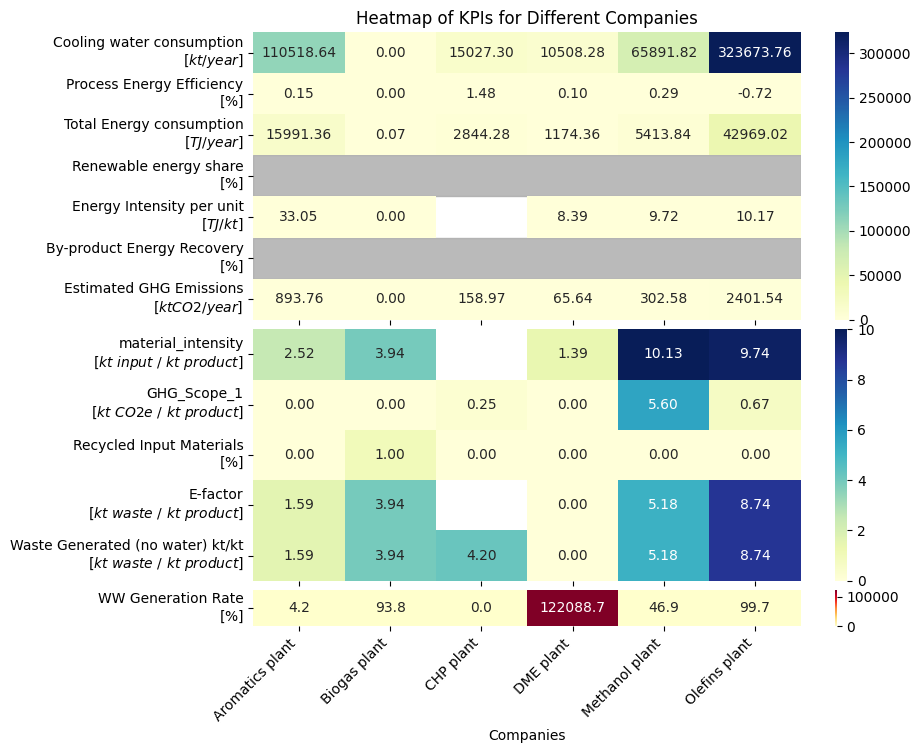

/tmp/ipykernel_37165/4272630341.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to ../export/ch6/kpi_heatmap_new_kpi_with_intervention.png


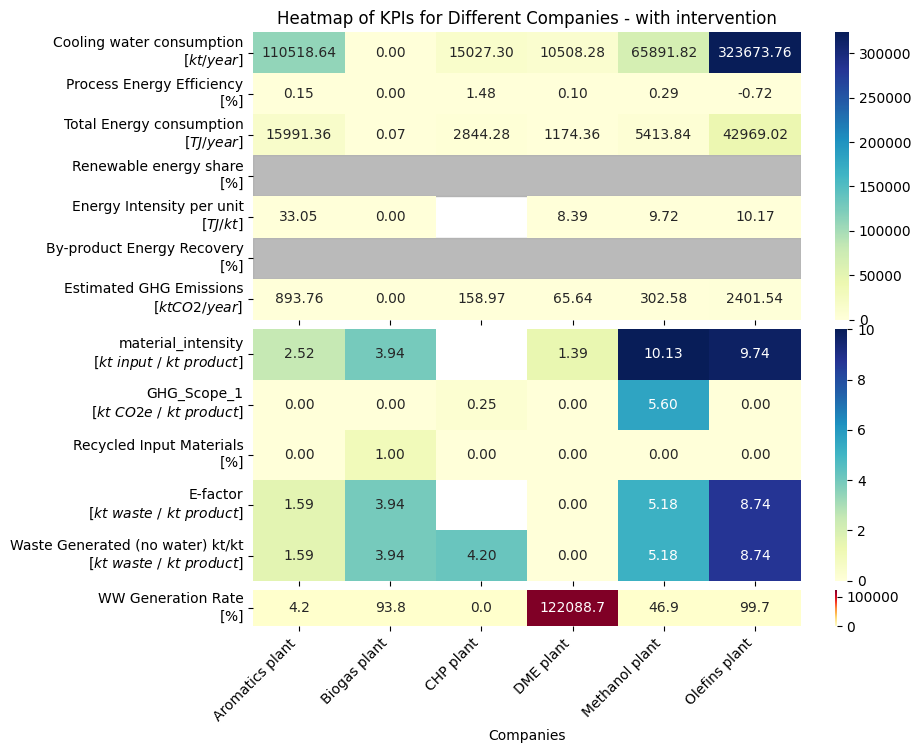

/tmp/ipykernel_37165/4272630341.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to ../export/ch6/kpi_heatmap_new_kpi_energy_only.png


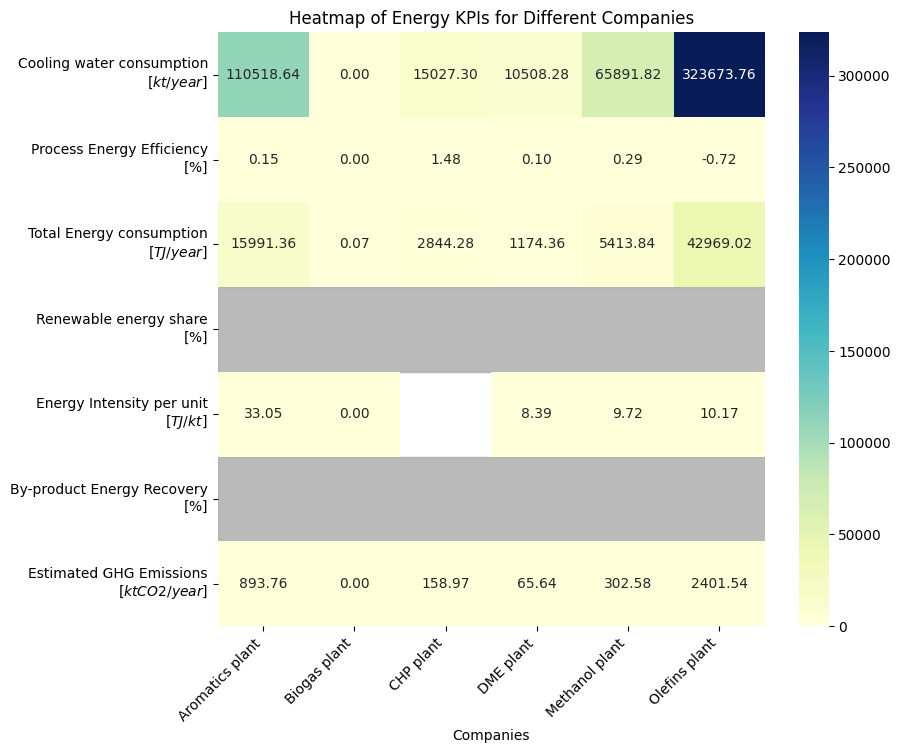

/tmp/ipykernel_37165/4272630341.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to ../export/ch6/kpi_heatmap_new_kpi_material_only.png


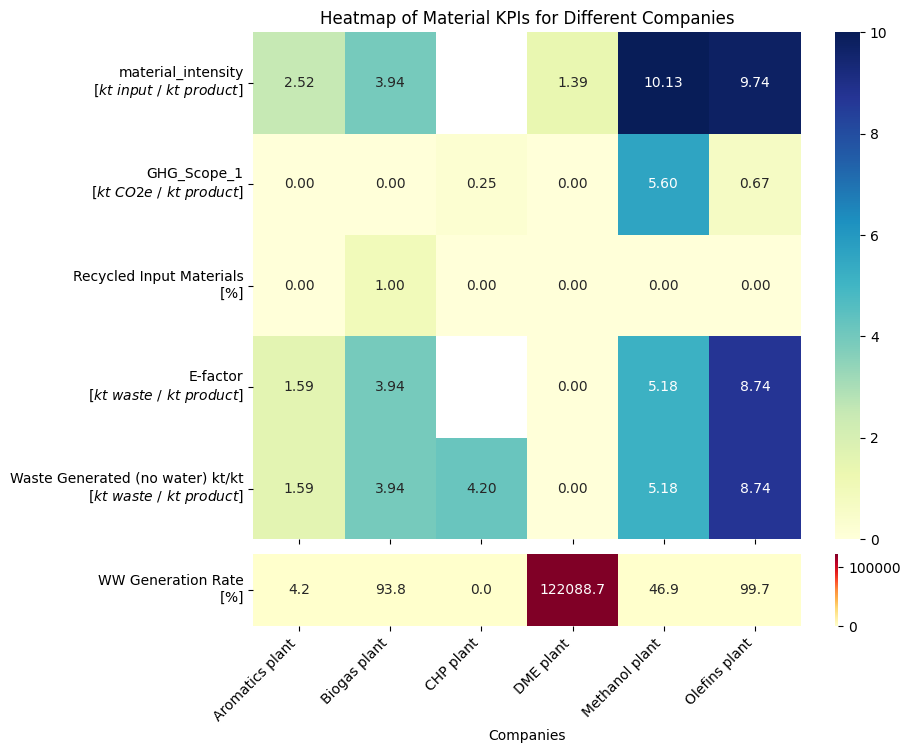

/home/rud/Documents/01_IE/08_INTR/03_Material_Analysis/project/.venv_INTR/lib64/python3.14/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/rud/Documents/01_IE/08_INTR/03_Material_Analysis/project/.venv_INTR/lib64/python3.14/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
/home/rud/Documents/01_IE/08_INTR/03_Material_Analysis/project/.venv_INTR/lib64/python3.14/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/rud/Documents/01_IE/08_INTR/03_Material_Analysis/project/.venv_INTR/lib64/python3.14/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
/tmp/ipykernel_37165/4272630341.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to ../export/ch6/kpi_heatmap_diff_with_intervention.png


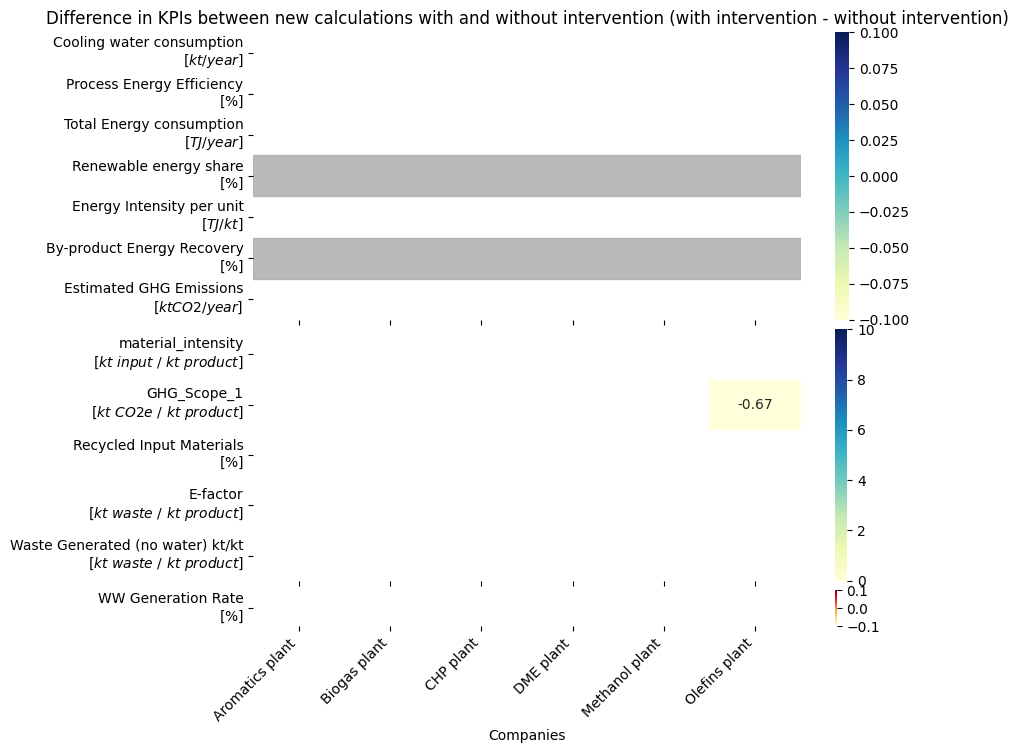

Saved to ../export/ch6/kpi_heatmap_rel_diff_with_intervention.png


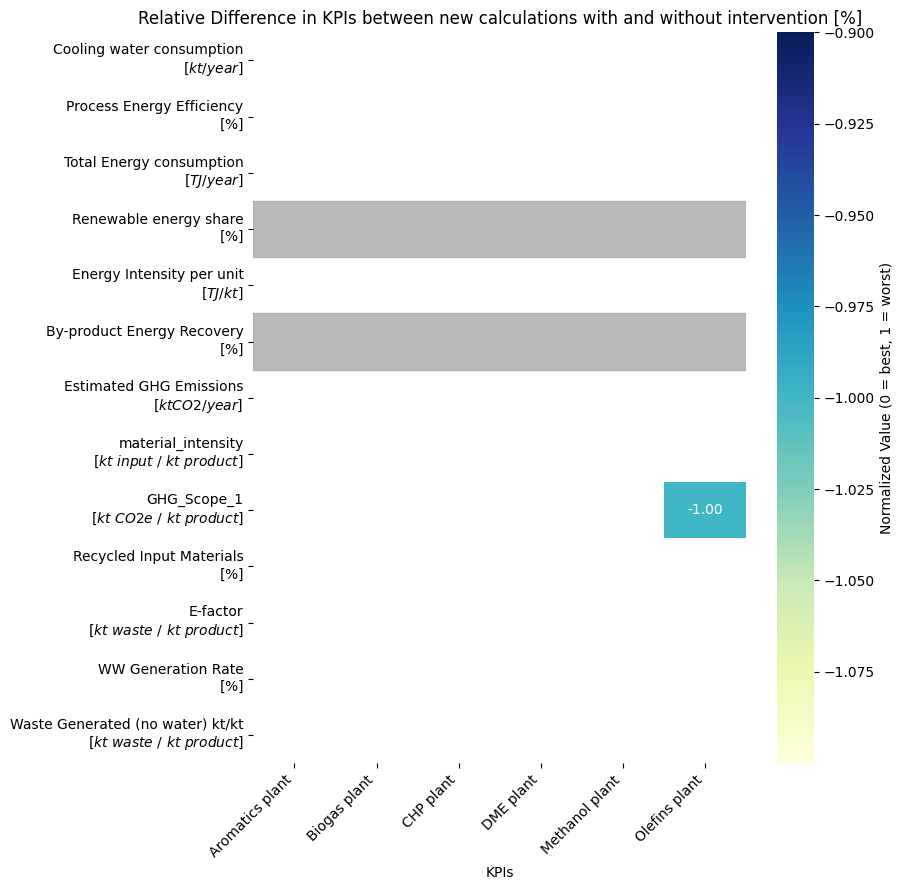

In [49]:
# Make a heatmap
import seaborn as sns
import matplotlib.pyplot as plt


def plot_kpi_heatmap(
    merged_df,
    energy_kpi_columns,
    material_kpi_columns,
    normalized=False,
    save_path=None,
    dpi=500,
    title="Heatmap of KPIs for Different Companies",
    kpi_set="all",
    energy_kpi_units=energy_kpi_units_mapping,
    material_kpi_units=material_kpi_units_mapping,
):
    """Plot a heatmap of KPIs per company.

    kpi_set controls which KPIs are shown:
        "all"      -> energy + material KPIs (material includes the outlier KPI)
        "energy"   -> only the energy KPIs
        "material" -> only the material KPIs (including the material outlier KPI)

    energy_kpi_units / material_kpi_units map a KPI name to its unit string;
    the unit is appended to the KPI label on a new line in square brackets.

    dpi controls the resolution of the saved PNG (only used when save_path is set).
    """
    if kpi_set not in ("all", "energy", "material"):
        raise ValueError("kpi_set must be one of 'all', 'energy', 'material'")

    show_energy = kpi_set in ("all", "energy")
    show_material = kpi_set in ("all", "material")

    def _label_with_units(name, units_map):
        """Append the unit (if any) on a new line, italicised, in square brackets."""
        unit = units_map.get(name, "")
        if not unit:
            return name
        # Render the unit in italics via mathtext (escape spaces and %).
        unit_italic = unit.replace("%", r"\%").replace(" ", r"\ ")
        return f"{name}\n[$\\mathit{{{unit_italic}}}$]"

    # default_cmap = "viridis"
    default_cmap = "YlGnBu"
    # If normalized is True, plot all on the same scale, otherwise plot on their own scales
    # The values are already normalized in the merged_df if normalized is True, so we can just plot them as is
    if normalized:
        # Select the columns to plot based on kpi_set
        plot_columns = []
        if show_energy:
            plot_columns += energy_kpi_columns[1:]
        if show_material:
            plot_columns += material_kpi_columns[1:]

        # Create figure
        fig, ax = plt.subplots(figsize=(9, 9))

        # Mark the energy rows only when energy KPIs are shown (and they come first)
        if show_energy:
            mark_row_index = [
                energy_kpi_columns[1:].index("Renewable energy share"),
                energy_kpi_columns[1:].index("By-product Energy Recovery"),
            ]
            for idx in mark_row_index:
                ax.add_patch(
                    plt.Rectangle(
                        (0, idx),
                        len(merged_df.columns),
                        1,
                        fill=True,
                        color="darkgrey",
                        alpha=0.8,
                    )
                )

        heatmap_df = merged_df.set_index("Company")[plot_columns].T
        units_lookup = {**energy_kpi_units, **material_kpi_units}
        heatmap_df.index = [
            _label_with_units(k, units_lookup) for k in heatmap_df.index
        ]
        sns.heatmap(
            heatmap_df,
            annot=True,
            cmap=default_cmap,
            ax=ax,
            cbar_kws={"label": "Normalized Value (0 = best, 1 = worst)"},
            fmt=".2f",
        )
        ax.set_title(title)
        ax.set_xlabel("KPIs")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=dpi)
            print(f"Saved to {save_path}")
        plt.show()
        return

    # Separate the outlier KPI from the rest
    material_outlier_kpi = "WW Generation Rate"
    material_kpi_columns_no_outlier = [
        col for col in material_kpi_columns if col != material_outlier_kpi
    ]

    # Prepare data for the heatmaps (only the parts we will actually plot)
    if show_energy:
        energy_data = merged_df.set_index("Company")[energy_kpi_columns[1:]].T.astype(
            float
        )
    if show_material:
        material_data = merged_df.set_index("Company")[
            material_kpi_columns_no_outlier[1:]
        ].T.astype(float)
        material_outlier_data = merged_df.set_index("Company")[
            [material_outlier_kpi]
        ].T.astype(float)

    # Build the list of subplots (and their relative heights) based on kpi_set
    panels = []  # list of ("type", height_ratio)
    if show_energy:
        panels.append(("energy", len(energy_kpi_columns)))
    if show_material:
        panels.append(("material", len(material_kpi_columns)))
        panels.append(("outlier", 1))

    fig, axes = plt.subplots(
        len(panels),
        1,
        figsize=(9, 9),
        gridspec_kw={
            "height_ratios": [h for _, h in panels],
            "hspace": 0.05,
        },
    )
    # Ensure axes is always iterable
    if len(panels) == 1:
        axes = [axes]
    panel_axes = dict(zip([name for name, _ in panels], axes))

    # The last panel keeps the x tick labels (company names); the others hide them
    last_panel_name = panels[-1][0]

    # Energy KPIs heatmap
    if show_energy:
        ax1 = panel_axes["energy"]
        # Mark the rows for "Renewable energy share" and "By-product Energy Recovery"
        # in a dark grey color and hide their values
        mark_row_index = [
            energy_kpi_columns[1:].index("Renewable energy share"),
            energy_kpi_columns[1:].index("By-product Energy Recovery"),
        ]
        for idx in mark_row_index:
            energy_data.iloc[idx, :] = None  # Hide values by setting to None
            ax1.add_patch(
                plt.Rectangle(
                    (0, idx),
                    len(energy_data.columns),
                    1,
                    fill=True,
                    color="darkgrey",
                    alpha=0.8,
                )
            )
        energy_data.index = [
            _label_with_units(k, energy_kpi_units) for k in energy_data.index
        ]
        sns.heatmap(
            energy_data,
            annot=True,
            cmap=default_cmap,
            ax=ax1,
            cbar_kws={"label": ""},
            fmt=".2f",
        )
        ax1.set_title(title)
        if last_panel_name == "energy":
            ax1.set_xlabel("Companies")
            ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
        else:
            ax1.set_xlabel("")
            ax1.set_xticklabels([])  # Hide x labels on plot
        ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

    # Material KPIs heatmap (excluding outlier)
    if show_material:
        ax2 = panel_axes["material"]
        material_data.index = [
            _label_with_units(k, material_kpi_units) for k in material_data.index
        ]
        sns.heatmap(
            material_data,
            annot=True,
            cmap=default_cmap,
            ax=ax2,
            cbar_kws={"label": ""},
            fmt=".2f",
            vmin=0,
            vmax=10,
        )
        if not show_energy:
            ax2.set_title(title)
        ax2.set_xlabel("")
        ax2.set_xticklabels([])  # Hide x labels on plot
        ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

        # Material outlier KPI heatmap
        ax3 = panel_axes["outlier"]
        material_outlier_data.index = [
            _label_with_units(k, material_kpi_units)
            for k in material_outlier_data.index
        ]
        sns.heatmap(
            material_outlier_data,
            annot=True,
            cmap="YlOrRd",
            ax=ax3,
            cbar_kws={"label": ""},
            fmt=".1f",
        )
        ax3.set_xlabel("Companies")
        ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha="right")
        ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0)

    # Save and show the plot
    plt.tight_layout()
    plt.subplots_adjust(left=0.22, right=0.98, bottom=0.22)
    if save_path:
        plt.savefig(save_path, dpi=dpi)
        print(f"Saved to {save_path}")
    plt.show()


# plot_kpi_heatmap(df_merged_kpi_old, energy_kpi_columns, material_kpi_columns_old,
#                  save_path="../export/kpi_heatmap_old_kpi.png",
#                  title="OLD - Heatmap of KPIs for Different Companies")
plot_kpi_heatmap(
    df_merged_kpi_new,
    energy_kpi_columns,
    material_kpi_columns,
    save_path="../export/ch6/kpi_heatmap_new_kpi.png",
    title="Heatmap of KPIs for Different Companies",
)
plot_kpi_heatmap(
    df_merged_kpi_w_int,
    energy_kpi_columns,
    material_kpi_columns,
    save_path="../export/ch6/kpi_heatmap_new_kpi_with_intervention.png",
    title="Heatmap of KPIs for Different Companies - with intervention",
)

# Energy-only and material-only heatmaps
plot_kpi_heatmap(
    df_merged_kpi_new,
    energy_kpi_columns,
    material_kpi_columns,
    save_path="../export/ch6/kpi_heatmap_new_kpi_energy_only.png",
    title="Heatmap of Energy KPIs for Different Companies",
    kpi_set="energy",
)
plot_kpi_heatmap(
    df_merged_kpi_new,
    energy_kpi_columns,
    material_kpi_columns,
    save_path="../export/ch6/kpi_heatmap_new_kpi_material_only.png",
    title="Heatmap of Material KPIs for Different Companies",
    kpi_set="material",
)

# # Plot df_merged_kpi_old - df_merged_kpi_new to see the difference in KPIs between old and new calculations
# df_kpi_diff = df_merged_kpi_new.copy()
# for col in energy_kpi_columns[1:] + material_kpi_columns[1:]:
#     df_kpi_diff[col] = df_merged_kpi_new[col] - df_merged_kpi_old[col]
# plot_kpi_heatmap(df_kpi_diff, energy_kpi_columns, material_kpi_columns,
#                  save_path="../export/ch6/kpi_heatmap_diff_new_minus_old.png",
#                  title="Difference in KPIs between new and old calculations (new - old)")

# # Plot (df_merged_kpi_new - df_merged_kpi_old)/df_merged_kpi_old to see the relative difference in KPIs between old and new calculations
# df_kpi_rel_diff = df_merged_kpi_new.copy()
# for col in energy_kpi_columns[1:] + material_kpi_columns[1:]:
#     df_kpi_rel_diff[col] = (df_merged_kpi_new[col] - df_merged_kpi_old[col]) / df_merged_kpi_old[col] * 100
#     df_kpi_rel_diff[col] = df_kpi_rel_diff[col].replace(0.0, np.nan)
# plot_kpi_heatmap(df_kpi_rel_diff, energy_kpi_columns, material_kpi_columns,
#                  save_path="../export/ch6/kpi_heatmap_rel_diff_new_minus_old.png",
#                  title="Relative Difference in KPIs between new and old calculations (new - old) [%]")

# Plot difference for new with intervention vs new without intervention => If 0.0 then nan to avoid plotting
df_kpi_intervention_diff = df_merged_kpi_w_int.copy()
for col in energy_kpi_columns[1:] + material_kpi_columns[1:]:
    df_kpi_intervention_diff[col] = df_merged_kpi_w_int[col] - df_merged_kpi_new[col]
    df_kpi_intervention_diff[col] = df_kpi_intervention_diff[col].replace(0.0, np.nan)
plot_kpi_heatmap(
    df_kpi_intervention_diff,
    energy_kpi_columns,
    material_kpi_columns,
    save_path="../export/ch6/kpi_heatmap_diff_with_intervention.png",
    title="Difference in KPIs between new calculations with and without intervention (with intervention - without intervention)",
)

# Plot percentage difference for new vs new with intervention => If 0.0 then nan to avoid plotting
df_kpi_intervention_diff = df_merged_kpi_w_int.copy()
for col in energy_kpi_columns[1:] + material_kpi_columns[1:]:
    df_kpi_intervention_diff[col] = (
        df_merged_kpi_w_int[col] - df_merged_kpi_new[col]
    ) / df_merged_kpi_new[col]
    df_kpi_intervention_diff[col] = df_kpi_intervention_diff[col].replace(0.0, np.nan)
plot_kpi_heatmap(
    df_kpi_intervention_diff,
    energy_kpi_columns,
    material_kpi_columns,
    save_path="../export/ch6/kpi_heatmap_rel_diff_with_intervention.png",
    title="Relative Difference in KPIs between new calculations with and without intervention [%]",
    normalized=True,
)


Saved to ../export/ch6/kpi_heatmap_new_kpi_normalized.png


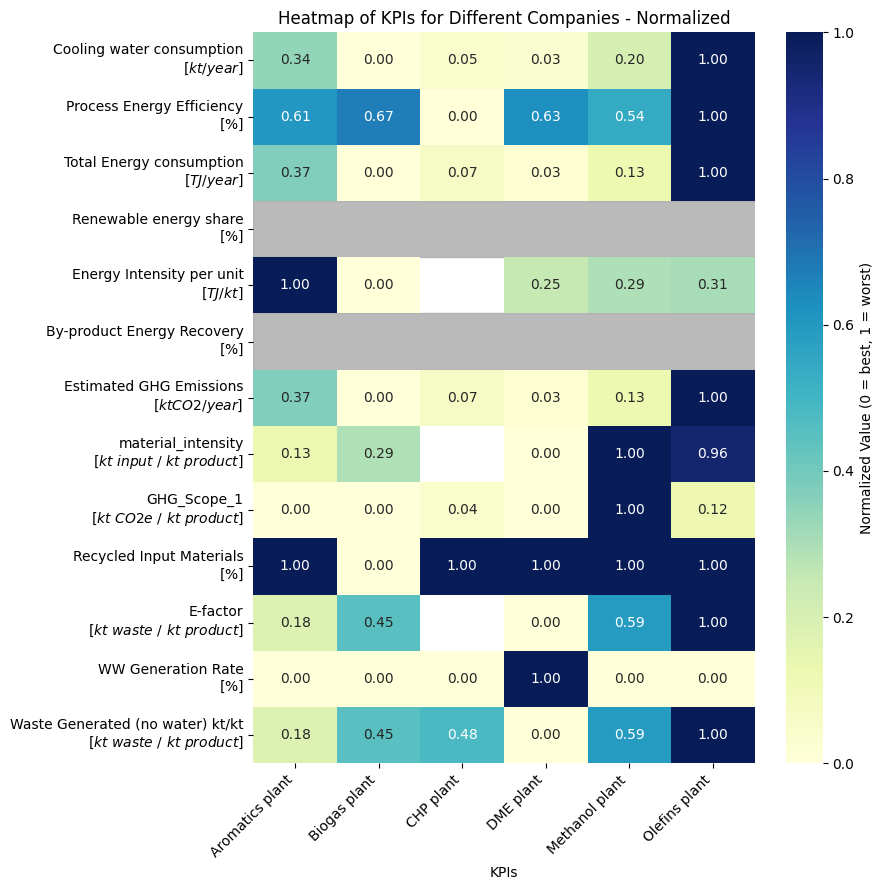

In [50]:
# Create a df of the kpis that are all normalized to be between 0 and 1 (the highest being 1)
normalized_kpis = df_merged_kpi_new.copy()
for col in energy_kpi_columns[1:] + material_kpi_columns[1:]:
    normalized_kpis[col] = (df_merged_kpi_new[col] - df_merged_kpi_new[col].min()) / (
        df_merged_kpi_new[col].max() - df_merged_kpi_new[col].min()
    )
    # If KPI is "process energy efficiency" or recycled input materials, reverse the normalization so that higher values are worse (since for these KPIs, higher is better)
    if col in ["Process Energy Efficiency", "Recycled Input Materials"]:
        normalized_kpis[col] = 1 - normalized_kpis[col]


# Create a heatmap of the normalized KPIs
plot_kpi_heatmap(
    normalized_kpis,
    energy_kpi_columns,
    material_kpi_columns,
    normalized=True,
    save_path="../export/ch6/kpi_heatmap_new_kpi_normalized.png",
    title="Heatmap of KPIs for Different Companies - Normalized",
)

# Network analysis

['Olefins plant', 'Methanol plant', 'Biogas plant', 'Aromatics plant', 'DME plant', 'CHP plant']
['Energy', 'Materials']


<Figure size 1400x1400 with 0 Axes>

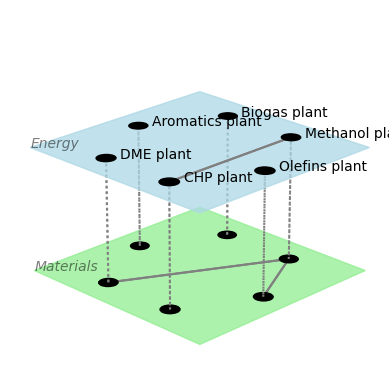

Cropped image saved to ../export/multilayer_network_no_connections.png


In [51]:
# file names
# with_wwtp_path = "../export/multilayer_network_with_wwtp.png"
# without_wwtp_path = "../export/multilayer_network_without_wwtp.png"
without_wwtp_path = "../export/multilayer_network_no_connections.png"  # no connections
# without_wwtp_path = "../export/multilayer_network_original_symbiosis.png" # original symbiosis


# 2. Create multilayer network
net = pymnet.MultiplexNetwork(couplings="categorical", fullyInterconnected=False)

include_wwtp = False

# Add layers
layers = ["Materials", "Energy"]
for layer in layers:
    net.add_layer(layer)

# Add the nodes: ['CHP plant', 'Olefins plant', 'Aromatics plant', 'Biogas plant', 'Methanol plant', 'DME plant']
companies = [
    "CHP plant",
    "Olefins plant",
    "Aromatics plant",
    "Biogas plant",
    "Methanol plant",
    "DME plant",
]
if include_wwtp:
    companies.append("WWTP")
for company in companies:
    for layer in layers:
        net.add_node(company, layer=layer)

# Add connections
# Methanol -> DME (Material)
# Olifins -> Methanol (Material)
# CHP -> Methanol (Energy)
net["Methanol plant", "DME plant", "Materials"] = 1
net["Olefins plant", "Methanol plant", "Materials"] = 1
# net['Olefins plant','Aromatics plant','Materials'] = 1
net["CHP plant", "Methanol plant", "Energy"] = 1

# Connect all companies but the WWTP to the WWTP in the Materials layer to represent wastewater discharge
tuple_for_wwtp_edges = []  # In this format: "((1,Materials),("WWTP",'Materials'))" for company "1"
if include_wwtp:
    for company in companies:
        if company != "WWTP":
            net[company, "WWTP", "Materials"] = 1
            tuple_for_wwtp_edges.append(((company, "Materials"), ("WWTP", "Materials")))

print(list(net.iter_nodes()))
print(list(net.iter_layers()))

# 3. Visualize
# Also show nodes without connections
# Only show labels on the Energy layer (top layer)
label_alpha = {
    (company, layer): (1.0 if layer == "Energy" else 0.0)
    for company in companies
    for layer in layers
}

plt.figure(figsize=(14, 14))
if include_wwtp:
    _edgeStyleDict = {
        tuple_for_wwtp_edges[i]: "dotted" for i in range(len(tuple_for_wwtp_edges))
    }
    _edgeColorDict = {
        tuple_for_wwtp_edges[i]: "blue" for i in range(len(tuple_for_wwtp_edges))
    }
    _nodeColorDict = {("WWTP", "Materials"): "blue", ("WWTP", "Energy"): "blue"}
else:
    _edgeStyleDict = {}
    _edgeColorDict = {}
    _nodeColorDict = {}
pymnet.draw(
    net,
    layout="circular",
    layerColorDict={"Materials": "lightgreen", "Energy": "lightblue"},
    nodeLabelAlphaDict=label_alpha,
    layerPadding=0.3,
    defaultLayerLabelLoc=(0, 0),  # pull label away from the clipped corner
    # azim=135,                            # rotate slightly to reduce rightward overhang
    azim=-45,  # rotate slightly to reduce rightward overhang
    # autoscale=True,
    layergap=1.5,
    defaultLayerLabelStyle="italic",
    defaultLayerLabelAlpha=0.5,
    edgeStyleDict=_edgeStyleDict,
    edgeColorDict=_edgeColorDict,
    nodeColorDict=_nodeColorDict,
)
# Save the plot
if include_wwtp:
    path = with_wwtp_path
else:
    path = without_wwtp_path
plt.savefig(path, dpi=150)
plt.show()

# Crop the 0.1 top and bottom of the plot to remove excess white space
from PIL import Image


def crop_image(path, save_path):
    with Image.open(path) as img:
        # Show before cropping
        img.show()
        width, height = img.size
        top = int(0.25 * height)
        bottom = int(0.85 * height)
        right = int(0.85 * width)
        left = int(0.2 * width)
        cropped_img = img.crop((left, top, right, bottom))
        cropped_img.show()
        cropped_img.save(save_path)
        print(f"Cropped image saved to {save_path}")


# crop_image(with_wwtp_path, with_wwtp_path)
crop_image(without_wwtp_path, without_wwtp_path)